<a href="https://colab.research.google.com/github/anteodor/Introduction-to-Machine-Learning/blob/main/assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 1 — Heart Disease Prediction using Decision Tree

**Student:** Anastasiia Teodorovska  
**Course:** Machine Learning  
**Task:** Build and evaluate a Decision Tree model for heart disease prediction using the UCI dataset.

## Importing the required libraries

At this stage, the essential Python libraries required for data processing, visualization, model development, and evaluation were imported.

The **pandas** library is used for data manipulation and analysis, enabling efficient handling of tabular datasets. The **numpy** library provides support for numerical computations and operations on arrays.

For data visualization, **matplotlib** and **seaborn** libraries were utilized. These tools allow for graphical representation of data, which is crucial for exploratory data analysis and interpretation of results.

In order to build and evaluate the machine learning model, components from the **scikit-learn** library were used. Specifically, the **DecisionTreeClassifier** was selected as the primary algorithm for classification.

Additionally, the **train_test_split** function was applied to divide the dataset into training and testing subsets, ensuring proper model validation. Evaluation metrics such as **accuracy_score**, **classification_report**, and **confusion_matrix** were used to assess the performance of the model.

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Loading and inspecting the dataset

In this stage, the heart disease dataset is loaded from an external online source using the **pandas** library.

The dataset is accessed via a direct URL link to the GitHub repository, which allows for efficient and reproducible data loading without the need for manual file handling.

After successfully loading the dataset, the first five rows are displayed to examine its structure, including column names, data types, and sample values. This initial inspection is essential for understanding the dataset and preparing it for further analysis.

In [142]:
url = "https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully.")
print()

print("First 5 rows of the dataset:")
display(df.head())

Dataset loaded successfully.

First 5 rows of the dataset:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## Exploratory Data Analysis (EDA)

In this stage, an exploratory data analysis (EDA) of the dataset is performed in order to better understand its structure, characteristics, and overall quality.

The analysis includes examining the dataset shape, data types, statistical properties, and the presence of missing values. This step is crucial as it provides insights into the data and helps determine whether any preprocessing is required before applying machine learning algorithms.

The dataset consists of **303 observations** and **14 features**, where all variables are numerical. This is advantageous, as it allows the model to be applied directly without the need for additional encoding of categorical variables.

Furthermore, the dataset does not contain missing values, which simplifies the preprocessing stage and ensures that no imputation or data cleaning techniques are required.

Statistical analysis provides information about the distribution of each feature, including measures such as mean, standard deviation, minimum and maximum values. These metrics help identify potential outliers and understand the scale of the data.

In [143]:
shape_df = pd.DataFrame({
    "Metric": ["Rows", "Columns"],
    "Value": [df.shape[0], df.shape[1]]
})

print("Dataset Shape:")
display(shape_df)

Dataset Shape:


,Metric,Value
0,Rows,303
1,Columns,14


In [144]:
info_df = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Non-Null Count": df.notnull().sum().values
})

print("\nDataset Info:")
display(info_df)


Dataset Info:


,Column,Data Type,Non-Null Count
0,age,int64,303
1,sex,int64,303
2,cp,int64,303
3,trestbps,int64,303
4,chol,int64,303
5,fbs,int64,303
6,restecg,int64,303
7,thalach,int64,303
8,exang,int64,303
9,oldpeak,float64,303


In [145]:
print("\nStatistical Summary:")
display(df.describe().T)


Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [146]:
missing_df = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": df.isnull().sum().values
})

print("\nMissing Values:")
display(missing_df)


Missing Values:


,Column,Missing Values
0,age,0
1,sex,0
2,cp,0
3,trestbps,0
4,chol,0
5,fbs,0
6,restecg,0
7,thalach,0
8,exang,0
9,oldpeak,0


## Feature selection and train-test split

In this stage, the dataset is divided into input features (**X**) and the target variable (**y**). The target variable represents the presence of heart disease, which is the main outcome to be predicted by the model.

All remaining columns are treated as input features, containing medical and physiological attributes of patients.

After separating the features and the target, the dataset is split into training and testing subsets using an **80/20 ratio**. This approach ensures that the model is trained on one portion of the data and evaluated on previously unseen data, allowing for an objective assessment of its performance.

To ensure reproducibility of the results, a fixed random state is used during the splitting process.

Additionally, **stratified sampling** is applied to preserve the original class distribution in both the training and testing datasets. This is particularly important for classification tasks, as it prevents bias caused by imbalanced data and improves the reliability of model evaluation.

In [147]:
# Separating features and target
X = df.drop(columns=["target"])
y = df["target"]

# Display shapes in table format
shape_split_df = pd.DataFrame({
    "Dataset": ["Features (X)", "Target (y)"],
    "Rows": [X.shape[0], y.shape[0]],
    "Columns": [X.shape[1], 1]
})

print("Feature and Target Overview:")
display(shape_split_df)

Feature and Target Overview:


,Dataset,Rows,Columns
0,Features (X),303,13
1,Target (y),303,1


In [148]:
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display split info
split_df = pd.DataFrame({
    "Dataset": ["Training Set", "Testing Set"],
    "Rows": [X_train.shape[0], X_test.shape[0]],
    "Columns": [X_train.shape[1], X_test.shape[1]]
})

print("Train/Test Split Overview:")
display(split_df)

Train/Test Split Overview:


,Dataset,Rows,Columns
0,Training Set,242,13
1,Testing Set,61,13


In [149]:
class_dist_df = pd.DataFrame({
    "Class": class_dist.index,
    "Percentage": class_dist.values
})

print("\nClass Distribution (%):")
display(class_dist_df)


Class Distribution (%):


,Class,Percentage
0,1,54.455446
1,0,45.544554


## Building and training the Decision Tree model

In this stage, a Decision Tree Classifier is constructed and trained using the training dataset.

The model is implemented using the **scikit-learn** library, which provides efficient tools for building machine learning algorithms. The Decision Tree algorithm was selected due to its interpretability and ability to model complex decision boundaries.

During the training process, the model learns patterns and relationships between input features and the target variable. This is achieved by recursively splitting the dataset into smaller subsets based on feature values, forming a tree-like structure of decision rules.

At each step, the algorithm selects the optimal feature and threshold that best separates the data according to a chosen impurity criterion (such as Gini impurity or entropy). The process continues until a stopping condition is met, such as reaching a maximum depth or achieving sufficiently pure nodes.

The trained model is then capable of making predictions by following the learned decision paths from the root of the tree to the corresponding leaf nodes.

In [150]:
# Creating the model with basic hyperparameters
model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

print("Model initialized with parameters:")
print(model)
print()

# Training the model
model.fit(X_train, y_train)

print("Model training completed successfully.")

Model initialized with parameters:
DecisionTreeClassifier(criterion='entropy', random_state=42)

Model training completed successfully.


## Model prediction and evaluation

In this stage, the trained Decision Tree model is used to make predictions on the test dataset. The predictions are compared with the true labels in order to evaluate the model's performance on previously unseen data.

The overall performance of the model is first assessed using the **accuracy** metric, which represents the proportion of correctly classified instances. The obtained accuracy value indicates that the model achieves a moderate level of predictive performance.

To further evaluate the model, a detailed **classification report** is generated. This report includes key metrics such as precision, recall, and F1-score for each class, providing a more comprehensive understanding of the model's behavior.

The results show that the model performs slightly better in predicting the positive class (presence of heart disease) compared to the negative class. This can be observed through higher recall and F1-score values for class 1.

Additionally, a comparison between training and testing accuracy is performed in order to assess the generalization ability of the model. If the training accuracy is significantly higher than the testing accuracy, this may indicate overfitting. In this case, the model demonstrates a reasonable balance between training and testing performance, suggesting acceptable generalization.

Overall, the evaluation metrics indicate that the Decision Tree model is capable of capturing meaningful patterns in the data, although there is still room for improvement in terms of predictive accuracy.

In [151]:
# Making predictions
y_pred = model.predict(X_test)

print("Predictions completed.\n")


# Accuracy
accuracy = accuracy_score(y_test, y_pred)

accuracy_df = pd.DataFrame({
    "Metric": ["Accuracy"],
    "Value": [round(accuracy, 4)]
})

print("Model Performance:")
display(accuracy_df)


Predictions completed.

Model Performance:


,Metric,Value
0,Accuracy,0.7541


In [152]:
# Train vs Test Accuracy
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

acc_compare_df = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "Accuracy": [round(train_accuracy, 4), round(test_accuracy, 4)]
})

print("Train vs Test Accuracy:")
display(acc_compare_df)

Train vs Test Accuracy:


,Dataset,Accuracy
0,Training,1.0000
1,Testing,0.7541


In [153]:
# Classification Report
report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

print("Classification Report:")
display(report_df)

Classification Report:


,precision,recall,f1-score,support
0,0.740741,0.714286,0.727273,28.000000
1,0.764706,0.787879,0.776119,33.000000
accuracy,0.754098,0.754098,0.754098,0.754098
macro avg,0.752723,0.751082,0.751696,61.000000
weighted avg,0.753705,0.754098,0.753698,61.000000


## Confusion Matrix

In this stage, a confusion matrix is constructed to provide a detailed evaluation of the model's classification performance.

The confusion matrix presents the number of correct and incorrect predictions made by the model, distinguishing between true positives, true negatives, false positives, and false negatives. This allows for a more precise understanding of where the model performs well and where it makes errors.

The results show that the model correctly classifies a significant portion of both classes, although some misclassifications are still present. In particular, the model demonstrates a slightly better ability to identify patients with heart disease (positive class) compared to those without it.

The presence of false positives and false negatives indicates that the model is not perfect and may benefit from further optimization or tuning. However, the overall distribution of values in the confusion matrix suggests that the model achieves a reasonable balance between sensitivity and specificity.

The heatmap visualization of the confusion matrix provides a clear and intuitive representation of the model's performance, making it easier to interpret the classification results.

Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,20,8
Actual 1,7,26


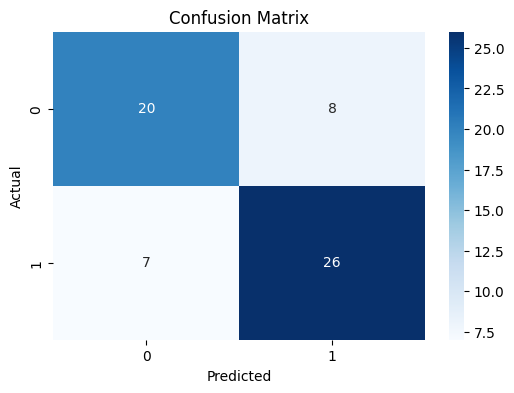

In [154]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

print("Confusion Matrix:")
display(cm_df)


# Visualization using heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## Decision Tree Visualization

In this stage, the trained Decision Tree model is visualized in order to better understand its internal structure and the logic used for classification.

The tree representation illustrates how the model makes decisions by recursively splitting the data according to feature values. Each internal node corresponds to a decision rule based on a specific feature, while each leaf node represents the final predicted class.

The visualization also provides additional information for each node, including the splitting condition, impurity value, number of samples, class distribution, and the predicted class. This makes the Decision Tree model highly interpretable compared to many other machine learning algorithms.

By analyzing the tree structure, it is possible to identify which features play a more significant role in the classification process and how the model separates patients with and without heart disease.

Overall, the visualization confirms that the Decision Tree model not only performs classification, but also provides transparency in the decision-making process, which is one of its main advantages.

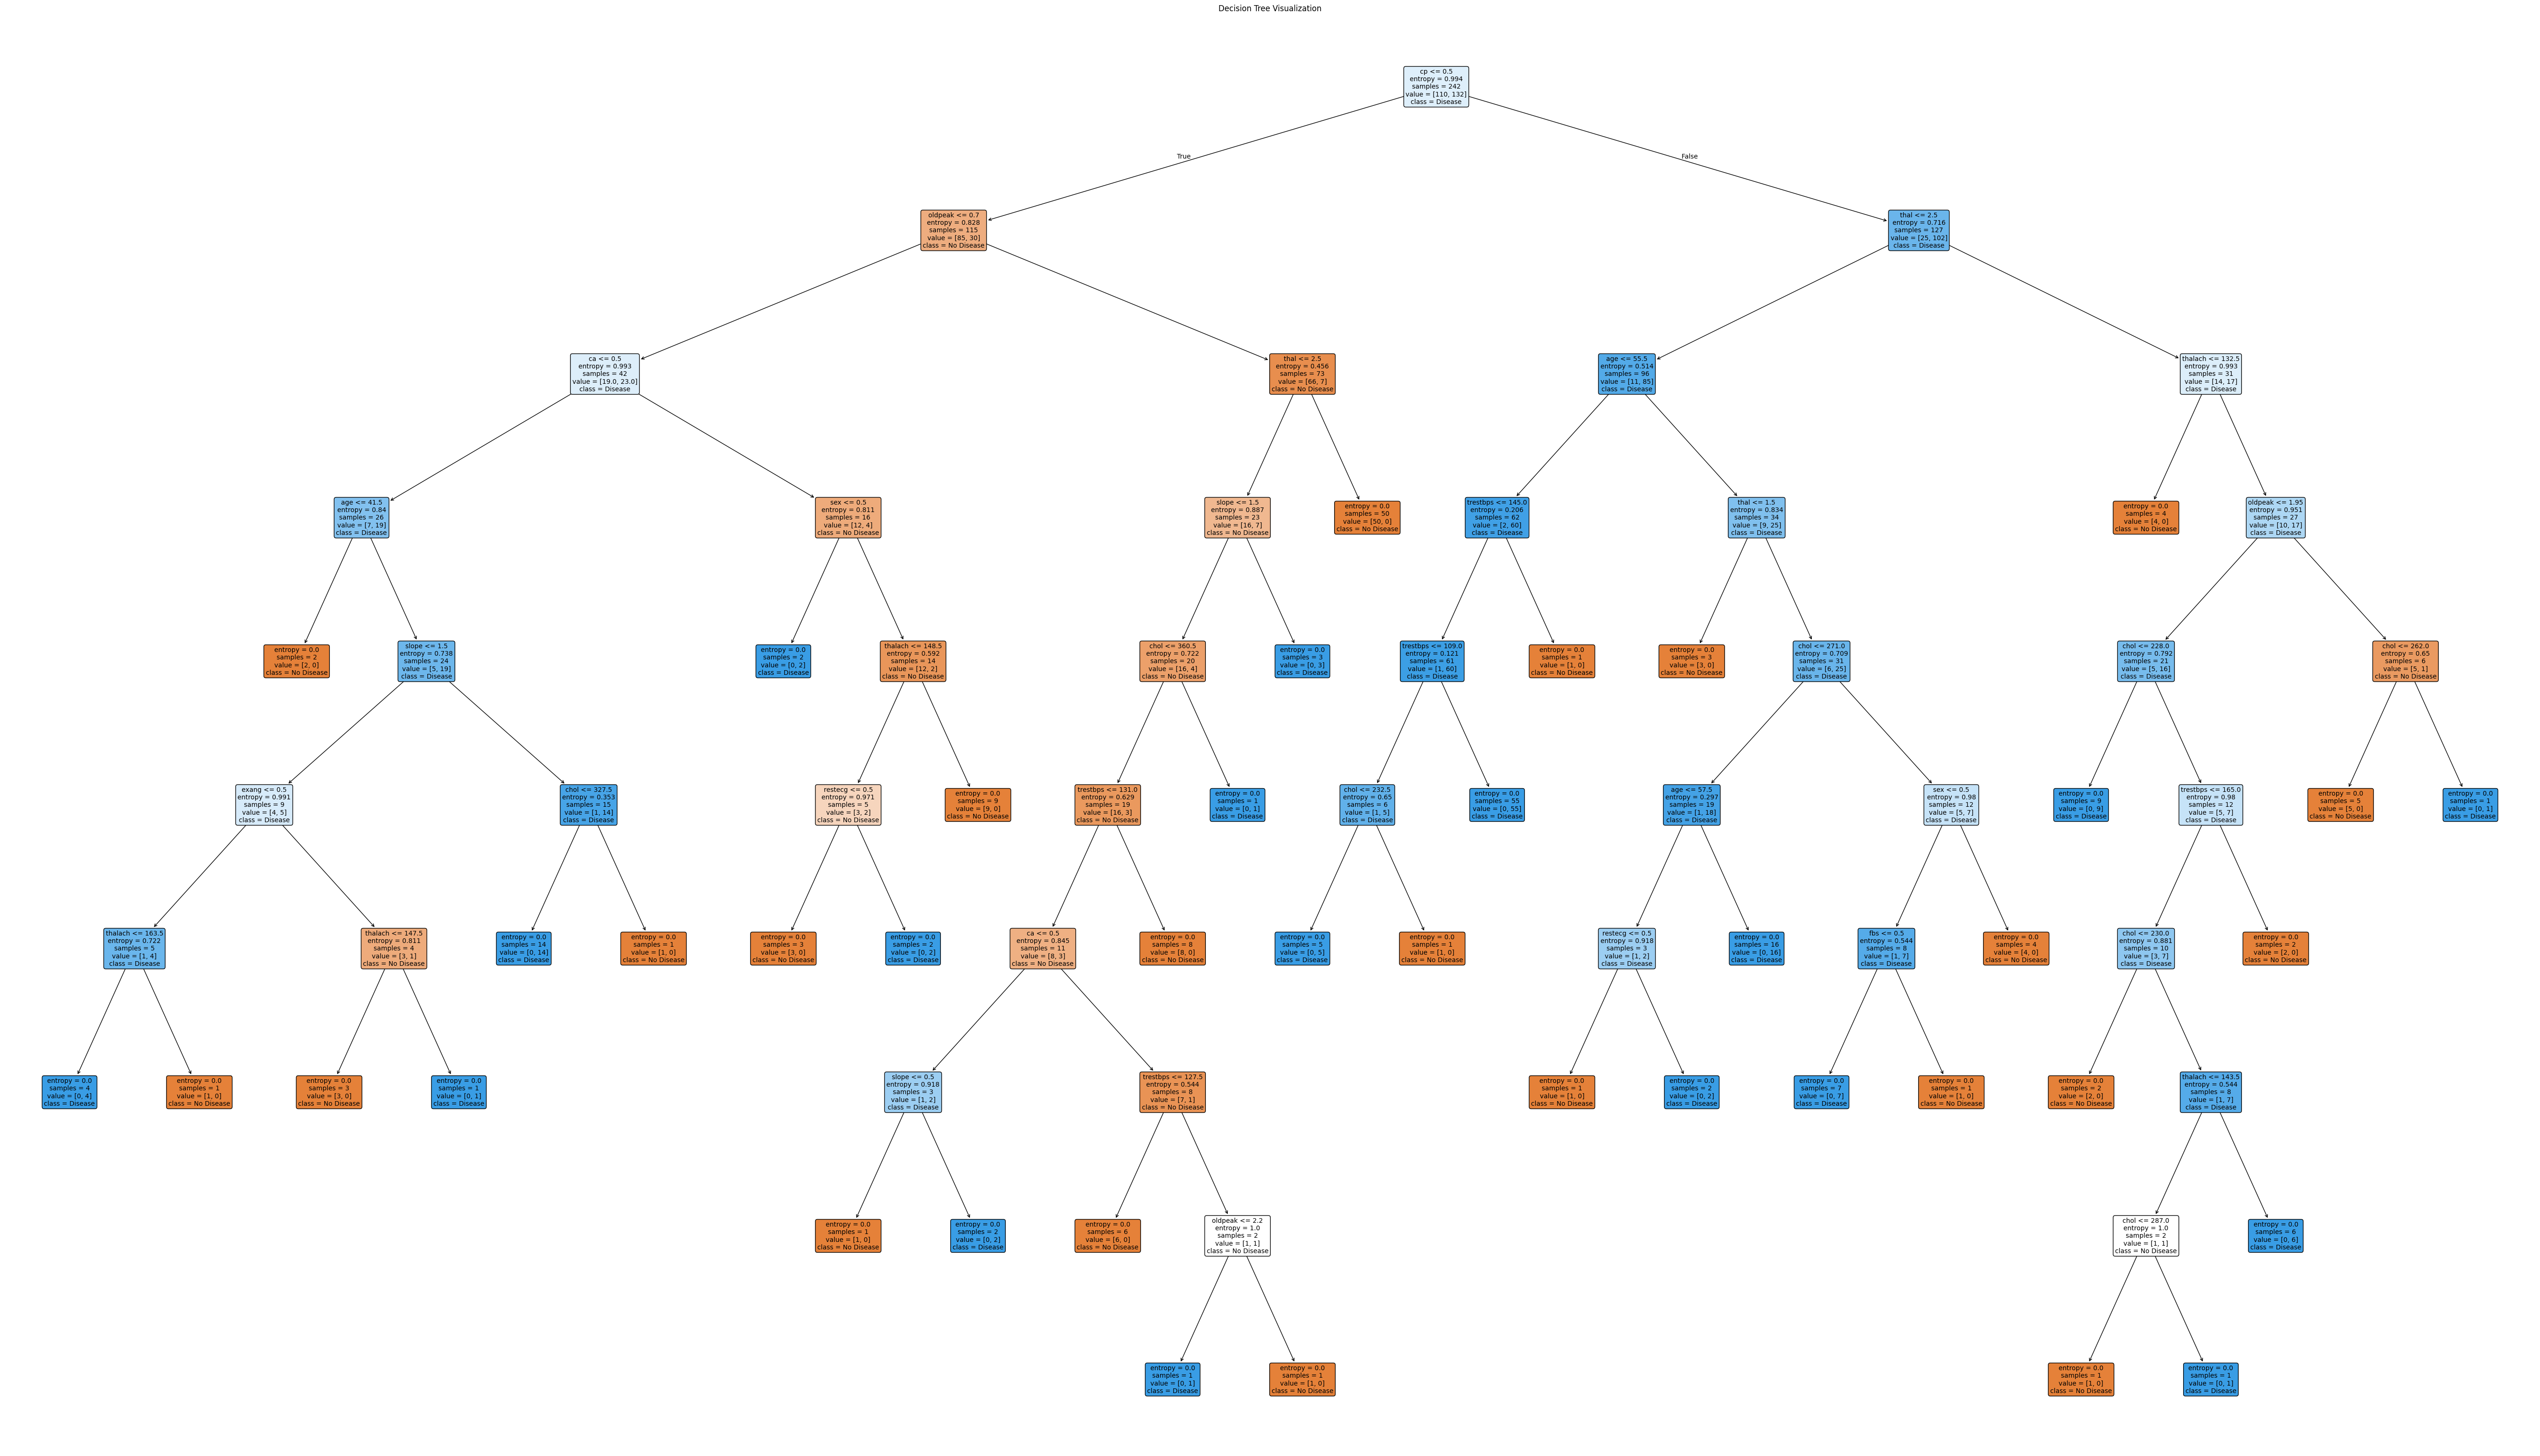

In [140]:
plt.figure(figsize=(70, 40))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree Visualization")
plt.show()

## Conclusions

In this work, a Decision Tree model was successfully developed to predict the presence of heart disease using the UCI dataset.

A comprehensive exploratory data analysis was conducted, including examination of the dataset structure, statistical properties, and verification of the absence of missing values. This ensured that the dataset was suitable for direct application of machine learning techniques without additional preprocessing.

The dataset was then divided into training and testing subsets using an 80/20 ratio, with stratified sampling applied to preserve the class distribution. This approach allowed for a reliable evaluation of the model on unseen data.

The Decision Tree Classifier was trained on the training dataset and evaluated on the test dataset. The model achieved an accuracy of approximately **75%**, indicating a satisfactory level of performance for a basic classification model.

Further evaluation using a classification report and confusion matrix provided deeper insight into the model's behavior. The results showed that the model is capable of identifying both positive and negative cases, although some misclassifications remain. The comparison between training and testing accuracy suggested that the model demonstrates acceptable generalization without severe overfitting.

Additionally, the visualization of the decision tree improved the interpretability of the model, allowing for a clear understanding of how decisions are made based on input features.

Overall, the Decision Tree algorithm proved to be an effective and interpretable approach for solving the heart disease classification problem. However, further improvements could be achieved through hyperparameter tuning or by applying more advanced models.